# Frequency domain examples

Example code which computes eigenvalues and eigenvectors of linearized radial perturbations of perfect and Eckart fluid stars.

In [1]:
include("params.jl")

Star(3.0e15, 0.002227848581428124, 0.0007548154792386719, 700.0, 0.8, NeutronStarOscillations.var"#EOS_ε#Star##0"{Float64, Float64}(700.0, 2.25), NeutronStarOscillations.var"#EOS_p#Star##1"{Float64, Float64}(700.0, 2.25), NeutronStarOscillations.var"#dp_dε#Star##2"{Float64, Float64}(700.0, 2.25), NeutronStarOscillations.var"#d2p_dε2#Star##3"{Float64, Float64}(700.0, 2.25), 0.0001, 0.0001, 10.0, 1.0, 5.0, 1.0, 7.548154792386719e-10, 7.54815479238672e-7, "/Users/lennoxkeeble/.julia/dev/NeutronStarOscillations/Results/Data/", "/Users/lennoxkeeble/.julia/dev/NeutronStarOscillations/Results/Figures/", 1.0e-15, 10, 100000000000, 1.0e-15, 1.0e-6, 1.0e-6, 200, 5, Main.xi_ID, Main.du_ID, Main.ddu_dr_ID, 0.1, 0.1, 0.0005, 0.04, 50, 0.05)

In [2]:
nPointsMatrix = 500;
h1_shoot = 4e-2;
h2_shoot = h1_shoot / 2;
h3_shoot = h1_shoot / 4;
h_TOV = 1e-5;

## Perfect fluid star in the cowling approximation

In [3]:
cowling = true;

In [4]:
@time compute_eigensystem(PF_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h2_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h3_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing perfect fluid Cowling eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 13.050159 seconds (93.38 M allocations: 3.635 GiB, 15.30% gc time, 96.90% compilation time: 3% of which was recompilation)
Computing perfect fluid Cowling eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 15.157254 seconds (92.06 M allocations: 3.663 GiB, 18.78% gc time, 82.51% compilation time)
Computing perfect fluid Cowling eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 12.795368 seconds (93.80 M allocations: 3.734 GiB, 15.97% gc time, 87.07% compilation time)


In [5]:
# load eigensystems. Eigenvalues are linear frequencies squared, i.e., ν^2 where ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(PF_star, h1_shoot, cowling);
init_freqs_2, shooting_freqs_2, radii_2, evecs_2, resids_2, ret_2 = load_eigensystem(PF_star, h2_shoot, cowling);
init_freqs_3, shooting_freqs_3, radii_3, evecs_3, resids_3, ret_3 = load_eigensystem(PF_star, h3_shoot, cowling);

In [6]:
# check convergence
diff_12 = abs.(shooting_freqs_1 .- shooting_freqs_2)
diff_23 = abs.(shooting_freqs_2 .- shooting_freqs_3)
prod(@. ((diff_23 < diff_12) || diff_23 == diff_12 == 0.0)) ? println("FREQUENCIES CONVERGING") : println("FREQUENCIES NOT CONVERGING")

FREQUENCIES CONVERGING


In [7]:
# linear frequencies in kHz (if the equilibrium configuration is unstable, then the squared frequencies will be negative and the code below will throw an error due to the sqrt)
freqs_1 = sqrt.(shooting_freqs_1);
freqs_2 = sqrt.(shooting_freqs_2);
freqs_3 = sqrt.(shooting_freqs_3);

In [8]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) PF shooting method return codes: ", ret_1)
println("(Med res) PF shooting method return codes: ", ret_2)
println("(High res) PF shooting method return codes: ", ret_3)

# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) PF fluid frequencies (kHz): ", freqs_1)
println("(Med res) PF fluid frequencies (kHz): ", freqs_2)
println("(High res) PF fluid frequencies (kHz): ", freqs_3)

*** NonlinearSolve return codes for shooting method ***
(Low res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(Med res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(High res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) PF fluid frequencies (kHz): [5.188233524964058, 8.691039581352696, 12.09328920306634, 15.452553782110227, 18.76485428757991]
(Med res) PF fluid frequencies (kHz): [5.188233546425662, 8.691039601599408, 12.093289226136825, 15.452553810225794, 18.764854323604414]
(High res) PF fluid frequencies (kHz): [5.188233547823963, 8.691039602847184, 12.093289227452507, 15.45255381168169, 18.76485432527268]


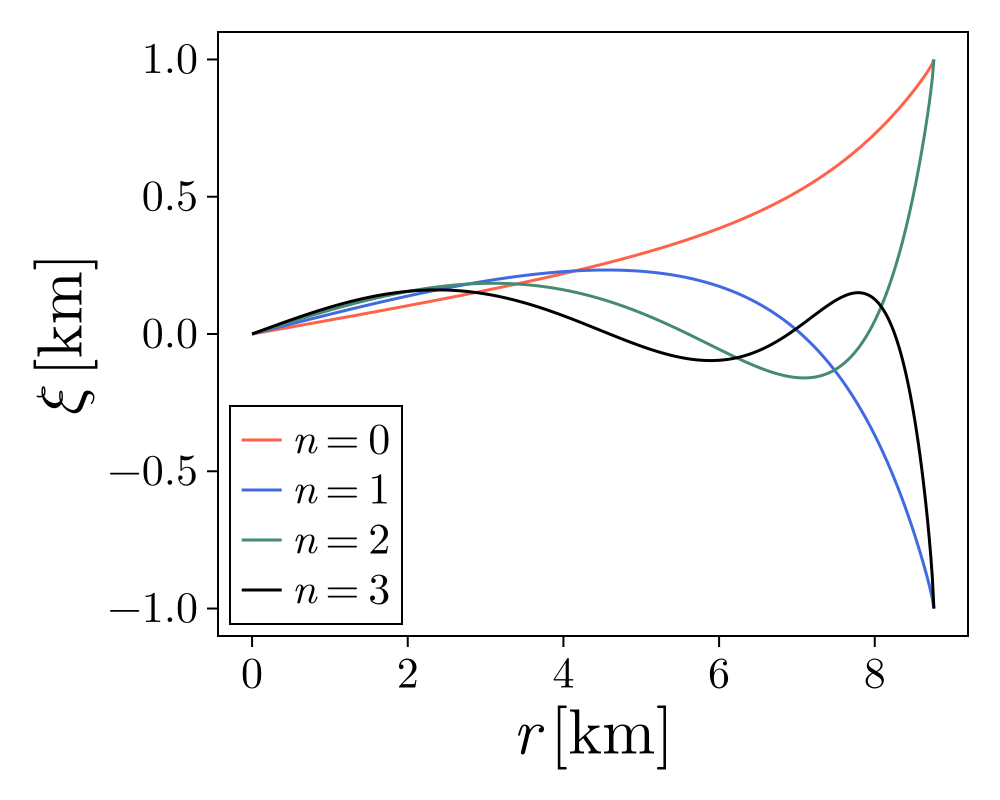

In [9]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot Cowling";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, PF_star, method; h=h3_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);

## Perfect fluid star

In [10]:
cowling = false;

In [11]:
@time compute_eigensystem(PF_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h2_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(PF_star, h3_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing perfect fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 11.443555 seconds (91.50 M allocations: 3.646 GiB, 16.83% gc time, 86.99% compilation time)
Computing perfect fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 14.425242 seconds (92.06 M allocations: 3.631 GiB, 15.91% gc time, 80.85% compilation time)
Computing perfect fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 16.960047 seconds (93.12 M allocations: 3.642 GiB, 13.21% gc time, 88.50% compilation time)


In [12]:
# load eigensystems. Eigenvalues are linear frequencies squared, i.e., ν^2 where ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(PF_star, h1_shoot, cowling);
init_freqs_2, shooting_freqs_2, radii_2, evecs_2, resids_2, ret_2 = load_eigensystem(PF_star, h2_shoot, cowling);
init_freqs_3, shooting_freqs_3, radii_3, evecs_3, resids_3, ret_3 = load_eigensystem(PF_star, h3_shoot, cowling);

In [13]:
# check convergence
diff_12 = abs.(shooting_freqs_1 .- shooting_freqs_2)
diff_23 = abs.(shooting_freqs_2 .- shooting_freqs_3)
prod(@. ((diff_23 < diff_12) || diff_23 == diff_12 == 0.0)) ? println("FREQUENCIES CONVERGING") : println("FREQUENCIES NOT CONVERGING")

FREQUENCIES CONVERGING


In [14]:
# linear frequencies in kHz (if the equilibrium configuration is unstable, then the squared frequencies will be negative and the code below will throw an error due to the sqrt)
freqs_1 = sqrt.(shooting_freqs_1);
freqs_2 = sqrt.(shooting_freqs_2);
freqs_3 = sqrt.(shooting_freqs_3);

In [15]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) PF shooting method return codes: ", ret_1)
println("(Med res) PF shooting method return codes: ", ret_2)
println("(High res) PF shooting method return codes: ", ret_3)

# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) PF fluid frequencies (kHz): ", freqs_1)
println("(Med res) PF fluid frequencies (kHz): ", freqs_2)
println("(High res) PF fluid frequencies (kHz): ", freqs_3)

*** NonlinearSolve return codes for shooting method ***
(Low res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(Med res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(High res) PF shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) PF fluid frequencies (kHz): [2.1872180664767553, 7.474887383477031, 11.259756339868117, 14.815590482476455, 18.251969581340358]
(Med res) PF fluid frequencies (kHz): [2.1872180795696115, 7.4748873984113136, 11.259756359198105, 14.815590507332049, 18.251969614050797]
(High res) PF fluid frequencies (kHz): [2.1872180804476673, 7.474887399352327, 11.259756360323207, 14.815590508643696, 18.251969615592213]


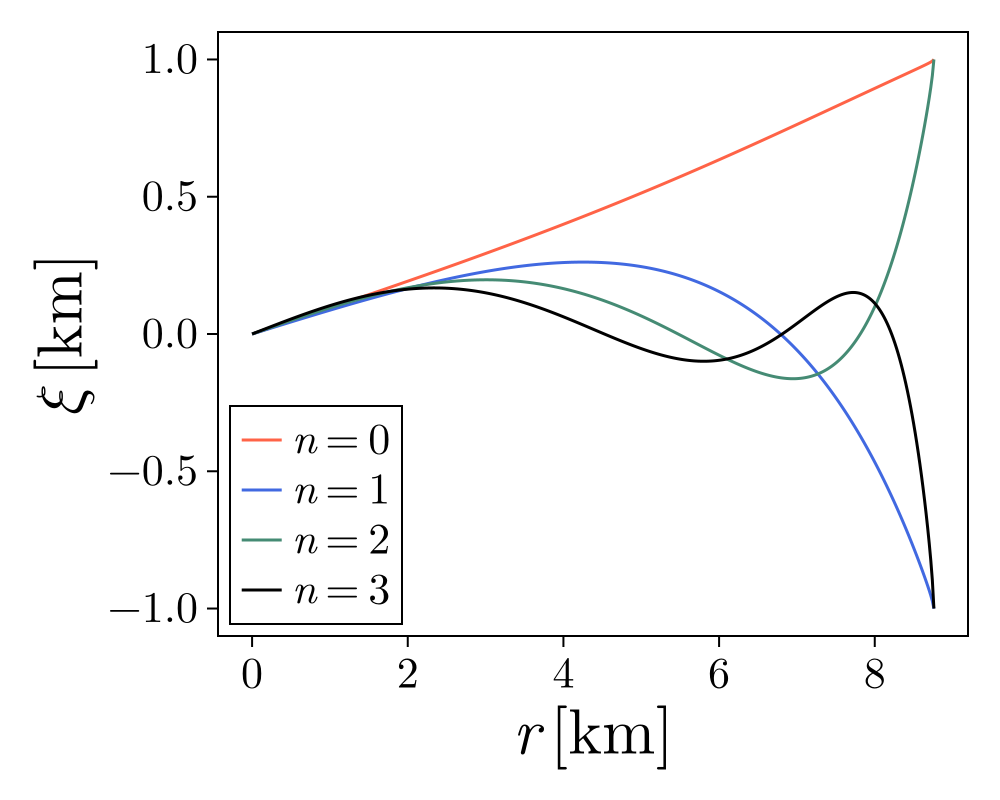

In [16]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, PF_star, method; h=h3_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);

## Eckart star

In [17]:
cowling = false;

In [18]:
@time compute_eigensystem(Eckart_star, h1_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(Eckart_star, h2_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);
@time compute_eigensystem(Eckart_star, h3_shoot, h_TOV, N_eigvals, nPointsMatrix, cowling; print_progress = true);

Computing Eckart fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 13.281204 seconds (93.99 M allocations: 3.668 GiB, 12.11% gc time, 94.48% compilation time)
Computing Eckart fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 16.412623 seconds (93.40 M allocations: 3.608 GiB, 12.72% gc time, 90.28% compilation time)
Computing Eckart fluid eigensystem...
Root finding eigenvalue 1 / 5
Root finding eigenvalue 2 / 5
Root finding eigenvalue 3 / 5
Root finding eigenvalue 4 / 5
Root finding eigenvalue 5 / 5
Computed all eigenvalues
 17.287964 seconds (92.78 M allocations: 3.573 GiB, 12.02% gc time, 98.24% compilation time)


In [19]:
# load eigensystems. Eigenvalues are (complex-valued) linear frequencies, i.e., ν = ω / (2π) and [ν] = kHz
init_freqs_1, shooting_freqs_1, radii_1, evecs_1, resids_1, ret_1 = load_eigensystem(Eckart_star, h1_shoot, cowling);
init_freqs_2, shooting_freqs_2, radii_2, evecs_2, resids_2, ret_2 = load_eigensystem(Eckart_star, h2_shoot, cowling);
init_freqs_3, shooting_freqs_3, radii_3, evecs_3, resids_3, ret_3 = load_eigensystem(Eckart_star, h3_shoot, cowling);


In [20]:
# check convergence
diff_12 = abs.(shooting_freqs_1 .- shooting_freqs_2)
diff_23 = abs.(shooting_freqs_2 .- shooting_freqs_3)
prod(@. ((diff_23 < diff_12) || diff_23 == diff_12 == 0.0)) ? println("FREQUENCIES CONVERGING") : println("FREQUENCIES NOT CONVERGING")

FREQUENCIES CONVERGING


In [21]:
# print return codes for the shooting method iterations
println("*** NonlinearSolve return codes for shooting method ***")
println("(Low res) Eckart shooting method return codes: ", ret_1)
println("(Med res) Eckart shooting method return codes: ", ret_2)
println("(High res) Eckart shooting method return codes: ", ret_3)

# print highest resolution frequencies
println("*** Linear frequencies ν = ω / 2π, [v] = κHz ***")
println("(Low res) Eckart fluid frequencies (kHz): ", shooting_freqs_1)
println("(Med res) Eckart fluid frequencies (kHz): ", shooting_freqs_2)
println("(High res) Eckart fluid frequencies (kHz): ", shooting_freqs_3)

*** NonlinearSolve return codes for shooting method ***
(Low res) Eckart shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(Med res) Eckart shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
(High res) Eckart shooting method return codes: ["Success", "Success", "Success", "Success", "Success"]
*** Linear frequencies ν = ω / 2π, [v] = κHz ***
(Low res) Eckart fluid frequencies (kHz): ComplexF64[2.193658169924702 - 5.5836986788407956e-5im, 7.510003959220854 - 0.00027745025626214626im, 11.36853980548801 - 0.0006027298560594982im, 15.054555280548682 - 0.0010402477262501653im, 18.700690401915114 - 0.0015967234732863075im]
(Med res) Eckart fluid frequencies (kHz): ComplexF64[2.1886681866784503 - 5.5694854262062245e-5im, 7.483635534340637 - 0.00027503862116810536im, 11.290667118842133 - 0.0005923449388057782im, 14.894192440519106 - 0.0010125348723349628im, 18.4219733932869 - 0.0015368126176258654im]
(High res) Eckart fluid

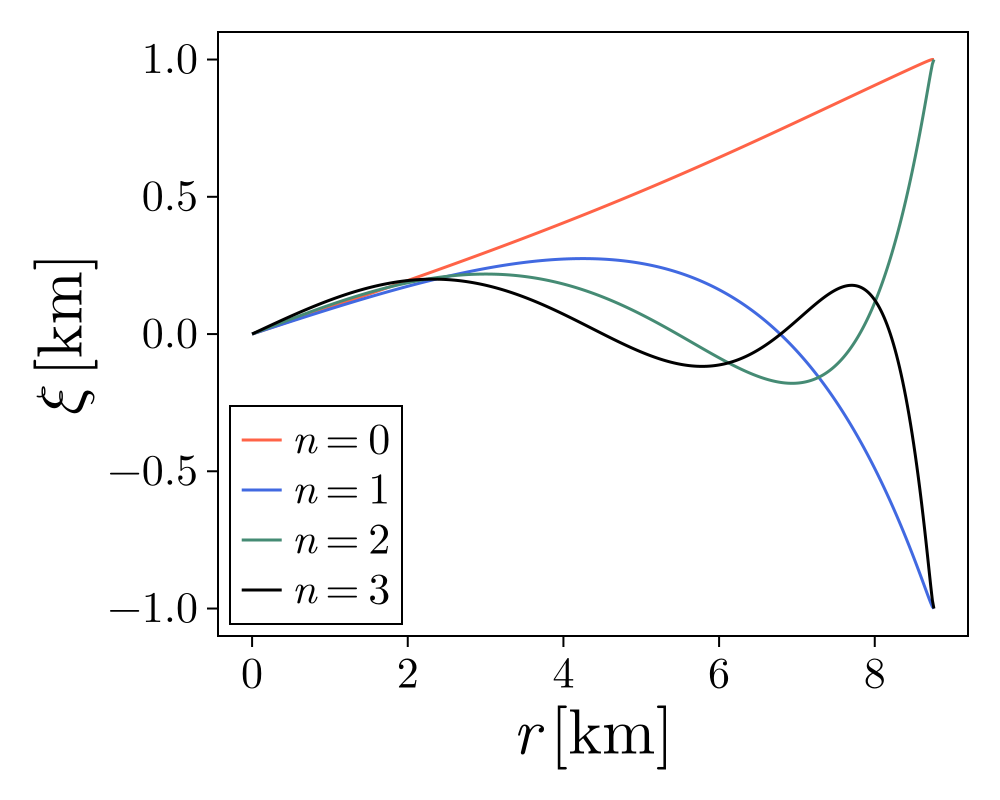

In [22]:
# plot eigenvectors
modes = [0, 1, 2, 3];
method = "Shoot";
xlabel = L"r\,[\mathrm{km}]";
ylabel = L"\xi\,[\mathrm{km}]";
legend = true;
labels = [L"n=%$mode" for mode in modes];
framevisible = true;

plot_fd_eigvecs(
    modes, Eckart_star, method; h=h3_shoot,
    xlabel = xlabel,
    ylabel = ylabel,
    legend = legend,
    labels = labels,
    position = :lb,
    framevisible = framevisible
);